# 07b v2 — Validación Externa SWaT A6 con Umbral Óptimo

## Qué cambió respecto a la versión anterior

La versión anterior usaba exclusivamente **τ = p99** (el percentil 99 de los errores de 
reconstrucción en datos normales). Este umbral está diseñado para tener muy pocos 
falsos positivos, pero sacrifica casi todo el recall. El resultado fue F1 < 0.10 y 
Recall < 4%.

Esta versión añade tres mejoras:

1. **Umbral óptimo desde la curva ROC** — se calcula el τ que maximiza el índice de 
   Youden (J = Recall − FPR), que es el criterio estándar para elegir el punto 
   operativo de un detector. También se calcula el τ que maximiza F1 directamente.

2. **Barrido completo de umbrales** — se evalúan τ en todos los percentiles 
   [p90, p95, p97.5, p99, p99.5] para ver cómo evoluciona el trade-off 
   Precision/Recall/F1 y así justificar qué umbral es más adecuado para cada 
   aplicación.

3. **Visualización del trade-off operativo** — curvas F1 vs τ, Precision-Recall 
   vs τ, y matriz de confusión para el umbral óptimo.

> **Nota sobre domain shift:** A6 (Dic 2019) y A7 (Jun 2020) son períodos distintos.
> Hay drift en algunas features (AIT501, FITs), pero los errores de reconstrucción 
> en A6 son *menores* que los umbrales internos de A7, lo que indica que el modelo 
> puede operar en A6. Se usa siempre la re-calibración con datos normales de A6.


## 0. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import joblib
import warnings
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix,
)
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 60)


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 1. Rutas del proyecto

In [3]:
current_dir = Path.cwd()
if (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "data").exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir.parent

A6_CSV_PATH            = PROJECT_ROOT / "data" / "clean" / "SWaT.A6_OTDataset_Dec_19" / "Dec2019_labeled.csv"
INTERNAL_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "tstr_internal_validation"
MODELS_DIR             = PROJECT_ROOT / "models" / "detectors" / "conv1d_tstr_internal"
EXTERNAL_RESULTS_DIR   = PROJECT_ROOT / "artifacts" / "tstr_external_validation_A6_v2"
EXTERNAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("A6_CSV_PATH  exists:", A6_CSV_PATH.exists())
print("INTERNAL_ARTIFACTS_DIR exists:", INTERNAL_ARTIFACTS_DIR.exists())
print("MODELS_DIR   exists:", MODELS_DIR.exists())


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
A6_CSV_PATH  exists: True
INTERNAL_ARTIFACTS_DIR exists: True
MODELS_DIR   exists: True


In [4]:
required_paths = [
    A6_CSV_PATH,
    INTERNAL_ARTIFACTS_DIR / "scaler_cont.pkl",
    INTERNAL_ARTIFACTS_DIR / "disc_max.pkl",
    INTERNAL_ARTIFACTS_DIR / "columns_config.json",
    INTERNAL_ARTIFACTS_DIR / "config.json",
    MODELS_DIR / "real_only",
    MODELS_DIR / "synthetic_only",
    MODELS_DIR / "real_plus_synthetic",
]
all_ok = True
for p in required_paths:
    exists = p.exists()
    print(f"  {'✅' if exists else '❌'} {p.name}")
    if not exists:
        all_ok = False
if all_ok:
    print("\n✅ Todos los artefactos encontrados.")
else:
    raise FileNotFoundError("Faltan artefactos — revisar rutas.")


  ✅ Dec2019_labeled.csv
  ✅ scaler_cont.pkl
  ✅ disc_max.pkl
  ✅ columns_config.json
  ✅ config.json
  ✅ real_only
  ✅ synthetic_only
  ✅ real_plus_synthetic

✅ Todos los artefactos encontrados.


## 2. Cargar artefactos del pipeline interno (A7 2020)

In [5]:
with open(INTERNAL_ARTIFACTS_DIR / "columns_config.json") as f:
    columns_config = json.load(f)
with open(INTERNAL_ARTIFACTS_DIR / "config.json") as f:
    internal_config = json.load(f)

continuous_cols = columns_config["continuous_cols"]
discrete_cols   = columns_config["discrete_cols"]
feature_cols    = columns_config["feature_cols"]
WINDOW_SIZE     = int(internal_config["window_size"])
STRIDE          = int(internal_config["stride"])
SCENARIOS       = internal_config["scenarios"]

scaler_cont = joblib.load(INTERNAL_ARTIFACTS_DIR / "scaler_cont.pkl")
disc_max    = joblib.load(INTERNAL_ARTIFACTS_DIR / "disc_max.pkl")

tau_dicts = {}
for scenario in SCENARIOS:
    tau_path = MODELS_DIR / scenario / "tau_dict.json"
    with open(tau_path) as f:
        tau_dicts[scenario] = json.load(f)

print(f"Scenarios: {SCENARIOS}")
print(f"Window size: {WINDOW_SIZE} | Stride: {STRIDE}")
print(f"Continuous: {len(continuous_cols)} | Discrete: {len(discrete_cols)} | Total: {len(feature_cols)}")
print("\nTau dicts (umbrales internos A7):")
for sc, taus in tau_dicts.items():
    print(f"  {sc:<25} p90={float(taus.get('p90',0)):.4f}  p95={float(taus.get('p95',0)):.4f}  "
          f"p99={float(taus.get('p99',0)):.4f}")


Scenarios: ['real_only', 'synthetic_only', 'real_plus_synthetic']
Window size: 60 | Stride: 5
Continuous: 23 | Discrete: 26 | Total: 49

Tau dicts (umbrales internos A7):
  real_only                 p90=0.3600  p95=0.4527  p99=0.5796
  synthetic_only            p90=0.4988  p95=0.5871  p99=1.7256
  real_plus_synthetic       p90=0.2552  p95=0.3009  p99=0.3278


## 3. Cargar A6 y aplicar etiquetas del log

In [6]:
a6_df = pd.read_csv(A6_CSV_PATH, low_memory=False)
a6_df["t_stamp"] = pd.to_datetime(a6_df["t_stamp"], errors="coerce")
a6_df = a6_df.dropna(subset=["t_stamp"]).reset_index(drop=True)
print(f"A6 shape: {a6_df.shape} | Período: {a6_df['t_stamp'].min()} → {a6_df['t_stamp'].max()}")


A6 shape: (13201, 87) | Período: 2019-12-06 10:05:00 → 2019-12-06 13:45:00


In [7]:
DATE = a6_df["t_stamp"].dt.date.mode()[0]
print(f"Fecha: {DATE}")

# 5 ciclos del Segundo ataque (Disrupt Sensor and Actuator)
# El Primer ataque (Historian Exfiltration) es de red — no visible en CSV
ATTACK_WINDOWS = [
    ("12:30:00", "12:33:00"),   # Ciclo 1 — 180 segundos
    ("12:43:00", "12:46:00"),   # Ciclo 2
    ("12:56:00", "12:59:00"),   # Ciclo 3
    ("13:09:00", "13:12:00"),   # Ciclo 4
    ("13:22:00", "13:25:00"),   # Ciclo 5
]

a6_df["attack_label"] = 0
for start_str, end_str in ATTACK_WINDOWS:
    t_start = pd.Timestamp(f"{DATE} {start_str}")
    t_end   = pd.Timestamp(f"{DATE} {end_str}")
    mask = (a6_df["t_stamp"] >= t_start) & (a6_df["t_stamp"] < t_end)
    a6_df.loc[mask, "attack_label"] = 1
    print(f"  {start_str}–{end_str}: {mask.sum():4d} filas")

attack_rows = (a6_df["attack_label"]==1).sum()
print(f"\nTotal ataque: {attack_rows} ({100*attack_rows/len(a6_df):.1f}%)")
print(f"Total normal:  {(a6_df['attack_label']==0).sum()} ({100*(a6_df['attack_label']==0).sum()/len(a6_df):.1f}%)")


Fecha: 2019-12-06
  12:30:00–12:33:00:  180 filas
  12:43:00–12:46:00:  180 filas
  12:56:00–12:59:00:  180 filas
  13:09:00–13:12:00:  180 filas
  13:22:00–13:25:00:  180 filas

Total ataque: 900 (6.8%)
Total normal:  12301 (93.2%)


## 4. Verificar columnas, limpiar y escalar

In [8]:
missing_cont = [c for c in continuous_cols if c not in a6_df.columns]
missing_disc = [c for c in discrete_cols   if c not in a6_df.columns]
print(f"{'✅' if not missing_cont else '❌'} Continuas: {len(continuous_cols)} presentes")
print(f"{'✅' if not missing_disc else '❌'} Discretas: {len(discrete_cols)} presentes")
if missing_cont: print("  Faltantes:", missing_cont)
if missing_disc: print("  Faltantes:", missing_disc)

a6_work = a6_df[["t_stamp", "attack_label"] + feature_cols].copy()
for col in feature_cols:
    a6_work[col] = pd.to_numeric(a6_work[col], errors="coerce")

before = len(a6_work)
a6_work = a6_work.dropna(subset=feature_cols).reset_index(drop=True)
print(f"\nFilas: {before} → {len(a6_work)} (eliminadas: {before-len(a6_work)})")


✅ Continuas: 23 presentes
✅ Discretas: 26 presentes

Filas: 13201 → 13200 (eliminadas: 1)


In [9]:
# StandardScaler de A7 sobre continuas
a6_cont_scaled = pd.DataFrame(
    scaler_cont.transform(a6_work[continuous_cols]),
    columns=continuous_cols, index=a6_work.index
)

# Normalización discretas — pd.Series.reindex para garantizar alineación
disc_max_aligned = pd.Series(disc_max).reindex(discrete_cols).replace(0, 1)
if disc_max_aligned.isna().any():
    raise ValueError("disc_max no contiene todas las columnas discretas.")

a6_disc_scaled = a6_work[discrete_cols].copy() / disc_max_aligned
a6_scaled = pd.concat(
    [a6_cont_scaled.reset_index(drop=True), a6_disc_scaled.reset_index(drop=True)],
    axis=1
)[feature_cols]

print(f"A6 escalado: {a6_scaled.shape}")
print(f"Rango continuas: [{a6_scaled[continuous_cols].values.min():.2f}, "
      f"{a6_scaled[continuous_cols].values.max():.2f}]  (esperado ≈ [-4, 4])")


A6 escalado: (13200, 49)
Rango continuas: [-2.61, 25.76]  (esperado ≈ [-4, 4])


## 5. Diagnóstico de domain shift A7→A6

El StandardScaler fue ajustado sobre A7 2020. Si A6 2019 tiene diferente distribución,
las medias escaladas estarán alejadas de 0. Se muestra un resumen cuantitativo
y un histograma por feature para inspeccionarlo visualmente.

**Interpretación:**  |media| < 1 → compatible ✅ | 1–5 → drift moderado ⚠️ | > 5 → drift severo ❌

**Clave:** aunque exista drift en las features, los resultados solo se invalidan si el
error de reconstrucción medio en A6 supera el umbral interno de A7 (ratio > 1). Si el
ratio es < 1, el drift no impide usar el modelo — simplemente hay que re-calibrar τ.


In [10]:
cont_arr = a6_scaled[continuous_cols].values

drift_df = pd.DataFrame({
    "feature":     continuous_cols,
    "mean_scaled": cont_arr.mean(axis=0),
    "std_scaled":  cont_arr.std(axis=0),
    "abs_drift":   np.abs(cont_arr.mean(axis=0)),
}).sort_values("abs_drift", ascending=False)

moderate = (drift_df["abs_drift"] > 1).sum()
severe   = (drift_df["abs_drift"] > 5).sum()

print("=" * 65)
print("DIAGNÓSTICO DE DOMAIN SHIFT A7 (train) → A6 (test externo)")
print("=" * 65)
print(f"Features con |media| > 1σ (drift moderado): {moderate}/{len(continuous_cols)}")
print(f"Features con |media| > 5σ (drift severo):   {severe}/{len(continuous_cols)}")
print(f"Rango global continuas A6: [{cont_arr.min():.2f}, {cont_arr.max():.2f}]")
print()
print("Top 10 features con mayor drift:")
display(drift_df[["feature", "mean_scaled", "std_scaled"]].head(10))


DIAGNÓSTICO DE DOMAIN SHIFT A7 (train) → A6 (test externo)
Features con |media| > 1σ (drift moderado): 4/23
Features con |media| > 5σ (drift severo):   0/23
Rango global continuas A6: [-2.61, 25.76]

Top 10 features con mayor drift:


,feature,mean_scaled,std_scaled
3,AIT501.Pv,-2.0490,0.1724
13,FIT502.Pv,1.1134,0.0246
11,FIT401.Pv,1.0962,0.0054
12,FIT501.Pv,1.0950,0.0072
14,FIT503.Pv,0.9934,0.0170
20,PIT501.Pv,0.9564,0.0068
22,PIT503.Pv,0.9325,0.0071
10,FIT301.Pv,0.7271,0.7606
9,FIT201.Pv,0.5553,1.0059
18,LIT301.Pv,0.4707,0.3682


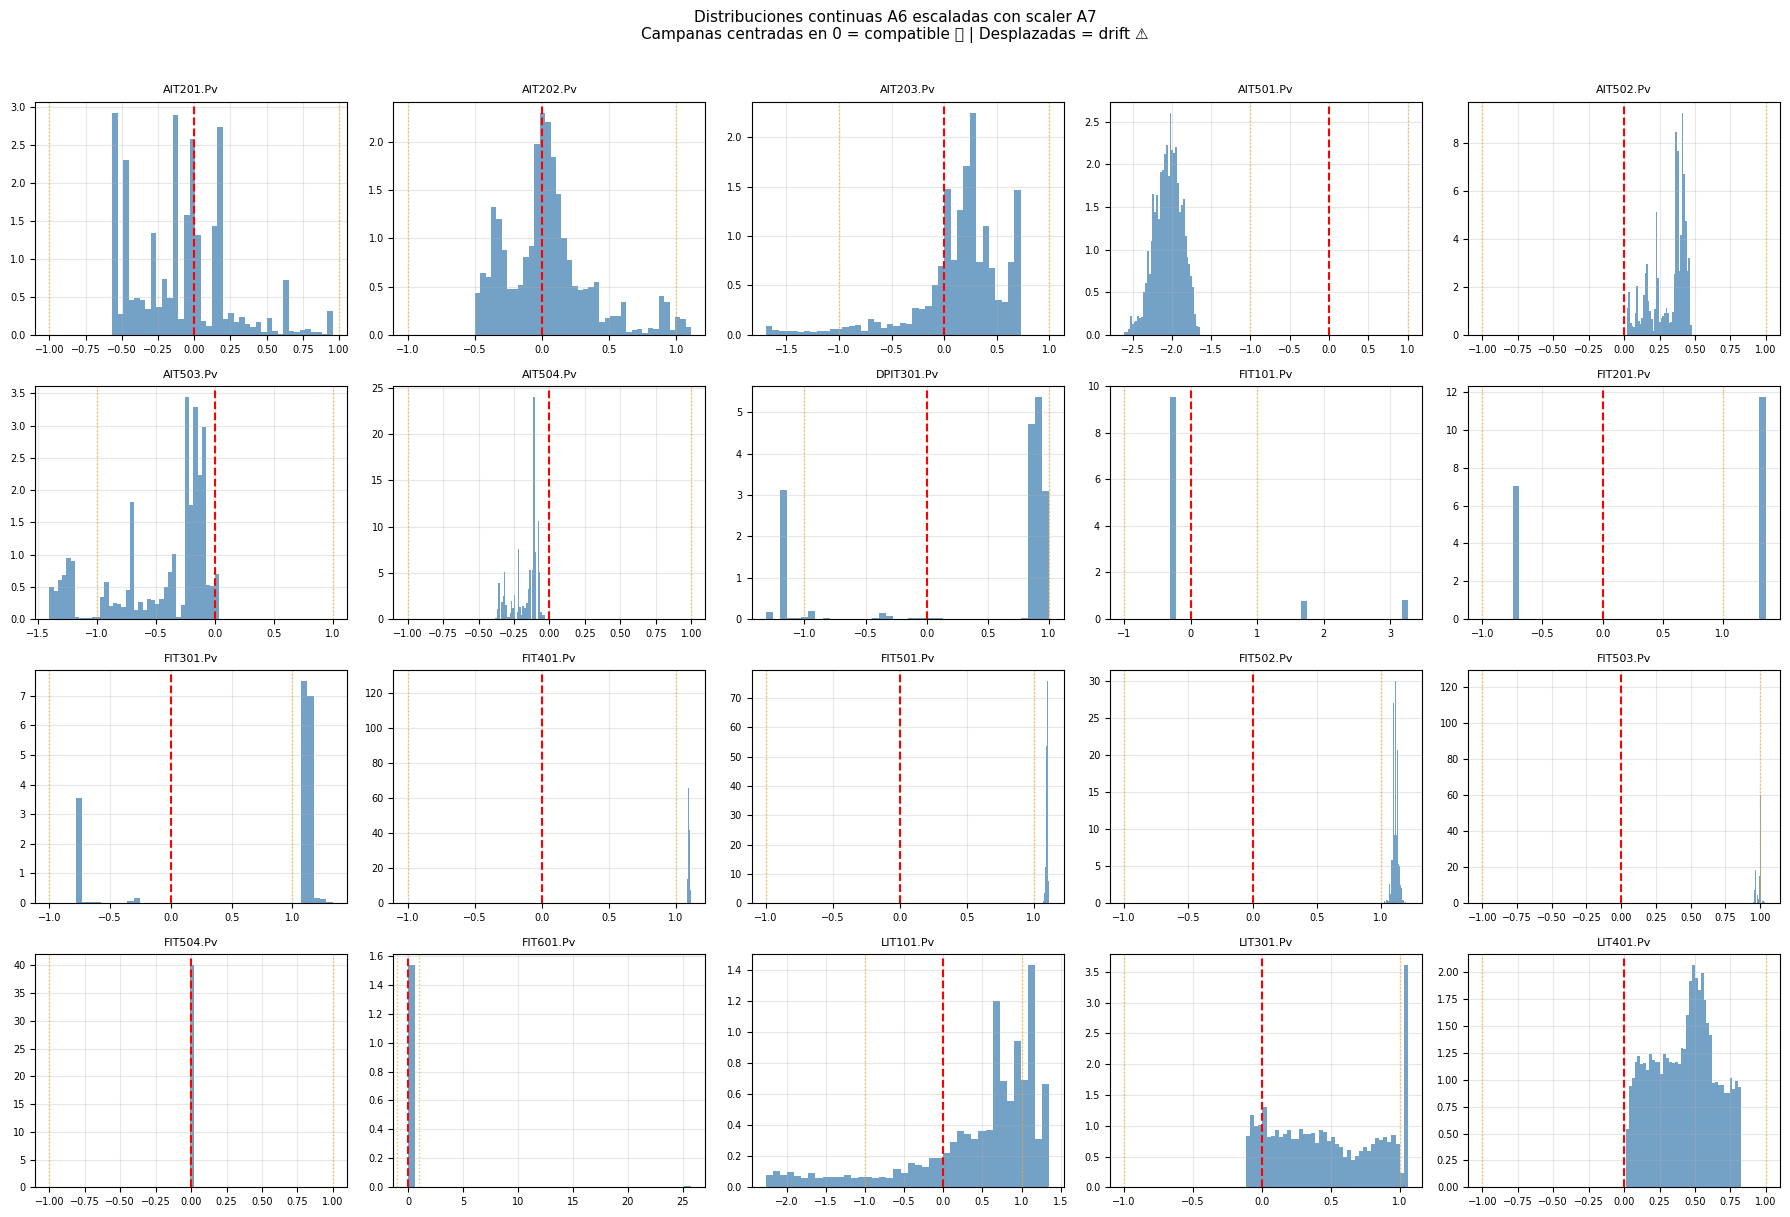

In [11]:
# Histogramas de distribuciones escaladas
n_plot = min(len(continuous_cols), 20)
ncols  = 5
nrows  = (n_plot + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows))
axes = axes.flatten()
for j, col in enumerate(continuous_cols[:n_plot]):
    axes[j].hist(a6_scaled[col].dropna(), bins=40, color="steelblue", alpha=0.75, density=True)
    axes[j].axvline(0,  color="red",    linestyle="--", lw=1.5, label="μ=0")
    axes[j].axvline(-1, color="orange", linestyle=":",  lw=1,   alpha=0.7)
    axes[j].axvline( 1, color="orange", linestyle=":",  lw=1,   alpha=0.7)
    axes[j].set_title(col, fontsize=8); axes[j].grid(True, alpha=0.3)
    axes[j].tick_params(labelsize=7)
for j in range(n_plot, len(axes)):
    axes[j].set_visible(False)
fig.suptitle(
    "Distribuciones continuas A6 escaladas con scaler A7\n"
    "Campanas centradas en 0 = compatible ✅ | Desplazadas = drift ⚠️",
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "domain_shift_distributions.png"), dpi=120, bbox_inches="tight")
plt.show()


## 6. Construcción de ventanas etiquetadas

In [12]:
def build_labeled_windows(scaled_df, labels, timestamps,
                         window_size=60, stride=5,
                         label_strategy="any", min_attack_ratio=0.1):
    """Ventanas deslizantes con etiqueta de ataque.
    
    label_strategy='any': positivo si CUALQUIER timestep es ataque.
    label_strategy='ratio': positivo si al menos min_attack_ratio son ataque.
    """
    windows, window_labels, attack_ratios = [], [], []
    start_times, end_times = [], []
    values     = scaled_df.values.astype(np.float32)
    labels_arr = np.asarray(labels).astype(int)
    times_arr  = np.asarray(timestamps)

    for start in range(0, len(values) - window_size + 1, stride):
        end   = start + window_size
        y_w   = labels_arr[start:end]
        ratio = float(np.mean(y_w))
        y_label = int(ratio > 0) if label_strategy == "any" else int(ratio >= min_attack_ratio)
        windows.append(values[start:end])
        window_labels.append(y_label)
        attack_ratios.append(ratio)
        start_times.append(str(times_arr[start]))
        end_times.append(str(times_arr[end - 1]))

    X = np.array(windows, dtype=np.float32)
    y = np.array(window_labels, dtype=int)
    meta = pd.DataFrame({"window_start": start_times, "window_end": end_times,
                         "label_any": y, "attack_ratio": attack_ratios})
    return X, y, meta


X_a6_seq, y_a6, window_meta = build_labeled_windows(
    a6_scaled[feature_cols], a6_work["attack_label"].values,
    a6_work["t_stamp"].values, window_size=WINDOW_SIZE, stride=STRIDE
)
X_a6 = np.transpose(X_a6_seq, (0, 2, 1)).astype(np.float32)  # (N, features, timesteps)

print(f"X_a6: {X_a6.shape} | y_a6: {y_a6.shape}")
print(f"Ventanas normales: {(y_a6==0).sum()} | Ventanas ataque: {(y_a6==1).sum()}")
print(f"Ratio de ataque: {100*y_a6.mean():.1f}%")


X_a6: (2629, 49, 60) | y_a6: (2629,)
Ventanas normales: 2391 | Ventanas ataque: 238
Ratio de ataque: 9.1%


In [13]:
# Estrategias alternativas de etiquetado
label_strategies = {"any": y_a6.copy()}
for ratio_th in [0.10, 0.20, 0.50]:
    key = f"ratio_{int(ratio_th*100)}"
    _, y_tmp, _ = build_labeled_windows(
        a6_scaled[feature_cols], a6_work["attack_label"].values,
        a6_work["t_stamp"].values, window_size=WINDOW_SIZE, stride=STRIDE,
        label_strategy="ratio", min_attack_ratio=ratio_th,
    )
    label_strategies[key] = y_tmp

display(pd.DataFrame([
    {"strategy": k, "normal": int((v==0).sum()), "attack": int((v==1).sum()),
     "attack_ratio_%": round(100*v.mean(), 1)}
    for k, v in label_strategies.items()
]))


,strategy,normal,attack,attack_ratio_%
0,any,2391,238,9.1000
1,ratio_10,2401,228,8.7000
2,ratio_20,2414,215,8.2000
3,ratio_50,2447,182,6.9000


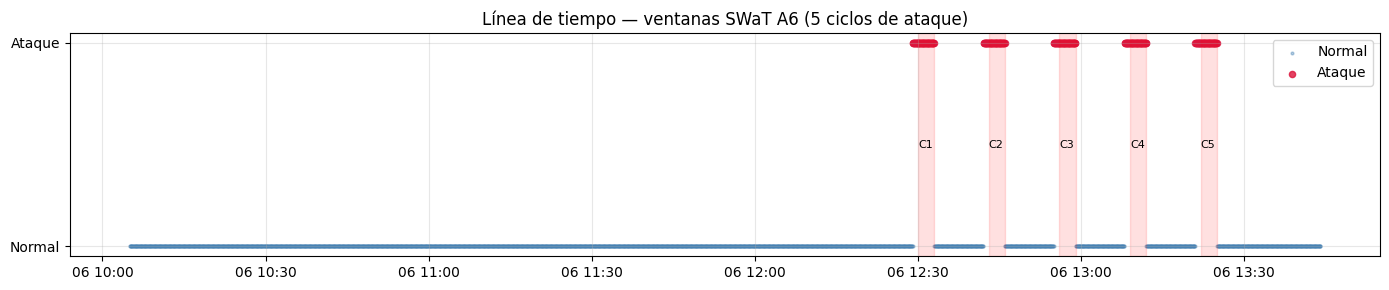

In [14]:
# Línea de tiempo de ventanas
fig, ax = plt.subplots(figsize=(14, 3))
ts = pd.to_datetime(window_meta["window_start"])
ax.scatter(ts[y_a6==0], np.zeros((y_a6==0).sum()), s=4,  c="steelblue", alpha=0.4, label="Normal")
ax.scatter(ts[y_a6==1], np.ones((y_a6==1).sum()),  s=20, c="crimson",   alpha=0.8, label="Ataque")
for i, (s, e) in enumerate(ATTACK_WINDOWS):
    t0 = pd.Timestamp(f"{DATE} {s}"); t1 = pd.Timestamp(f"{DATE} {e}")
    ax.axvspan(t0, t1, alpha=0.12, color="red"); ax.text(t0, 0.5, f"C{i+1}", fontsize=8, va="center")
ax.set_yticks([0,1]); ax.set_yticklabels(["Normal","Ataque"])
ax.set_title("Línea de tiempo — ventanas SWaT A6 (5 ciclos de ataque)"); ax.grid(True, alpha=0.3)
ax.legend(); plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "window_timeline.png"), dpi=120, bbox_inches="tight")
plt.show()


## 7. Arquitectura Conv1D y carga de modelos

La arquitectura es exactamente la misma que se usó en el entrenamiento interno:
dos bloques Conv1D + MaxPool en el encoder y dos ConvTranspose1D en el decoder.


In [15]:
class Conv1dAutoencoder(nn.Module):
    """Autoencoder Conv1D idéntico al entrenamiento interno.
    
    Encoder: Conv→ReLU→MaxPool × 2  (comprime seq_len: 60→15)
    Decoder: ConvTranspose→ReLU × 2  (expande 15→60)
    
    El error de reconstrucción MSE por ventana es el score de anomalía:
    error alto → la ventana es difícil de reconstruir → posible anomalía.
    """
    def __init__(self, input_channels):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose1d(32, input_channels, kernel_size=2, stride=2),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


In [16]:
input_channels = X_a6.shape[1]
models = {}
for scenario in SCENARIOS:
    state_path = MODELS_DIR / scenario / "model_state.pt"
    if not state_path.exists():
        raise FileNotFoundError(f"No encontrado: {state_path}")
    m = Conv1dAutoencoder(input_channels).to(device)
    m.load_state_dict(torch.load(state_path, map_location=device))
    m.eval()
    models[scenario] = m
    print(f"✅ {scenario:25s} — {sum(p.numel() for p in m.parameters()):,} parámetros")

print(f"\nin_channels={input_channels} | seq_len={WINDOW_SIZE}")


✅ real_only                 — 10,529 parámetros
✅ synthetic_only            — 10,529 parámetros
✅ real_plus_synthetic       — 10,529 parámetros

in_channels=49 | seq_len=60


## 8. Errores de reconstrucción en A6

El error de reconstrucción MSE por ventana es el **score de anomalía** del detector.
Un valor alto indica que el modelo no pudo reconstruir bien esa ventana → posible anomalía.

El análisis de domain shift más relevante no es comparar distribuciones de features,
sino comparar los errores de reconstrucción en A6 con los umbrales internos de A7:
- Ratio < 1 → los errores A6 son menores que el umbral A7 → **sin problema**
- Ratio > 2 → todos los errores de A6 superan el umbral A7 → **drift severo**


In [17]:
def reconstruction_errors(model, X, batch_size=256):
    """MSE de reconstrucción por ventana. Entrada: (N, features, timesteps)."""

    loader = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)),
                        batch_size=batch_size, shuffle=False)
    errors = []
    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            err = torch.mean((model(batch) - batch) ** 2, dim=(1, 2))
            errors.extend(err.cpu().numpy())
    return np.array(errors)

external_errors = {}
for sc, model in models.items():
    external_errors[sc] = reconstruction_errors(model, X_a6)

# Tabla de estadísticas
print(f"{'Scenario':<25} {'mean':>8} {'std':>8} {'p50':>8} {'p90':>8} {'p95':>8} {'p99':>8}")
print("-" * 75)
for sc in SCENARIOS:
    e = external_errors[sc]
    print(f"{sc:<25} {e.mean():>8.4f} {e.std():>8.4f} "
          f"{np.percentile(e,50):>8.4f} {np.percentile(e,90):>8.4f} "
          f"{np.percentile(e,95):>8.4f} {np.percentile(e,99):>8.4f}")


Scenario                      mean      std      p50      p90      p95      p99
---------------------------------------------------------------------------
real_only                   0.1560   0.0905   0.1264   0.2635   0.3197   0.5636
synthetic_only              0.2841   0.4067   0.2289   0.2940   0.3039   3.1580
real_plus_synthetic         0.1378   0.0771   0.1232   0.1718   0.1910   0.6392


In [18]:
# Comparación errores A6 vs umbrales internos A7
print("\nComparación error medio A6 vs τ_p99 internos A7:")
print(f"{'Scenario':<25} {'mean_A6':>8} {'τ_p99_A7':>10} {'ratio':>8}  Interpretación")
print("-" * 80)
for sc in SCENARIOS:
    e = external_errors[sc]; tau = float(tau_dicts[sc]["p99"]); ratio = e.mean() / tau
    interp = ("✅ Sin drift severo" if ratio < 1 else
              "⚠️  Drift moderado" if ratio < 2 else "❌ Drift severo")
    print(f"{sc:<25} {e.mean():>8.4f} {tau:>10.4f} {ratio:>8.2f}x  {interp}")

print()
print("Ratio < 1 → el error medio en A6 es MENOR que el umbral A7.")
print("Esto indica que la operación normal de A6 es reconstruida bien por el modelo.")
print("El domain shift en features individuales no impide usar el modelo en A6.")



Comparación error medio A6 vs τ_p99 internos A7:
Scenario                   mean_A6   τ_p99_A7    ratio  Interpretación
--------------------------------------------------------------------------------
real_only                   0.1560     0.5796     0.27x  ✅ Sin drift severo
synthetic_only              0.2841     1.7256     0.16x  ✅ Sin drift severo
real_plus_synthetic         0.1378     0.3278     0.42x  ✅ Sin drift severo

Ratio < 1 → el error medio en A6 es MENOR que el umbral A7.
Esto indica que la operación normal de A6 es reconstruida bien por el modelo.
El domain shift en features individuales no impide usar el modelo en A6.


## 9. Re-calibración de umbrales con datos normales de A6

Se usan las ventanas normales **antes del primer ataque** (antes de las 12:30)
para calcular τ calibrado sobre A6. Esta es la práctica estándar cuando hay
cualquier nivel de domain shift entre el dataset de entrenamiento y el de despliegue.

Los umbrales calculados aquí son los que se usan en el resto del análisis.


In [19]:
first_attack_time = pd.Timestamp(f"{DATE} 12:30:00")
mask_pre = a6_work["t_stamp"] < first_attack_time

a6_calib_scaled = a6_scaled[mask_pre.values].reset_index(drop=True)
calib_vals = a6_calib_scaled[feature_cols].values.astype(np.float32)
X_calib_seq = [calib_vals[s:s+WINDOW_SIZE]
               for s in range(0, len(calib_vals)-WINDOW_SIZE+1, STRIDE)]
X_calib = np.transpose(np.array(X_calib_seq, dtype=np.float32), (0, 2, 1))

print(f"Datos normales pre-ataque: {mask_pre.sum()} filas → {len(X_calib)} ventanas")

# Calcular errores en ventanas normales A6 para cada modelo
PERCENTILES_CALIB = [75, 80, 85, 90, 95, 97.5, 99, 99.5]
tau_dicts_a6 = {}
calib_errors  = {}

rows_calib = []
for sc, model in models.items():
    c_err = reconstruction_errors(model, X_calib)
    calib_errors[sc] = c_err
    tau_a6 = {f"p{str(p).replace('.','_')}": float(np.percentile(c_err, p))
              for p in PERCENTILES_CALIB}
    tau_dicts_a6[sc] = tau_a6
    rows_calib.append({"scenario": sc, "mean": c_err.mean(), "std": c_err.std(),
                        **{k: v for k, v in tau_a6.items()}})

calib_df = pd.DataFrame(rows_calib)
print("\nErrores de calibración A6 (ventanas normales pre-ataque):")
display(calib_df)


Datos normales pre-ataque: 8700 filas → 1729 ventanas

Errores de calibración A6 (ventanas normales pre-ataque):


,scenario,mean,std,p75,p80,p85,p90,p95,p97_5,p99,p99_5
0,real_only,0.1614,0.0899,0.1734,0.1845,0.1953,0.2490,0.3697,0.4010,0.5636,0.7067
1,synthetic_only,0.2954,0.4060,0.2745,0.2863,0.2934,0.2983,0.3101,0.3344,3.1929,3.8732
2,real_plus_synthetic,0.1472,0.0793,0.1602,0.1648,0.1710,0.1849,0.1954,0.1992,0.6433,0.7852


## 10. Selección del umbral óptimo

Esta es la sección central de la versión v2. Se calculan cuatro criterios de selección:

1. **τ_youden** — maximiza el índice de Youden J = Recall − FPR (criterio estándar ROC)
2. **τ_f1** — maximiza el F1 score directamente  
3. **τ_balanced_acc** — maximiza la balanced accuracy (media de Recall y Specificity)
4. **τ_p99** — el percentil 99 (referencia conservadora, igual que la versión anterior)

Los criterios 1, 2 y 3 se calculan barriendo todos los umbrales de la curva ROC/PR,
por lo que son los puntos óptimos **en el dataset de evaluación**. En producción se
usaría una partición de validación para evitar sobreajuste al umbral.


In [20]:
def compute_classification_metrics(y_true, scores, threshold):
    """Métricas de clasificación para un umbral dado."""

    y_pred = (scores > threshold).astype(int)
    tp = int(((y_pred==1) & (y_true==1)).sum())
    fp = int(((y_pred==1) & (y_true==0)).sum())
    tn = int(((y_pred==0) & (y_true==0)).sum())
    fn = int(((y_pred==0) & (y_true==1)).sum())
    precision   = tp / (tp + fp + 1e-10)
    recall      = tp / (tp + fn + 1e-10)
    f1          = 2*precision*recall / (precision + recall + 1e-10)
    specificity = tn / (tn + fp + 1e-10)
    fpr         = fp / (fp + tn + 1e-10)
    bal_acc     = (recall + specificity) / 2
    return {"threshold": float(threshold), "precision": float(precision),
            "recall": float(recall), "f1": float(f1),
            "balanced_accuracy": float(bal_acc), "specificity": float(specificity),
            "fpr": float(fpr), "tp": tp, "fp": fp, "tn": tn, "fn": fn}


def find_optimal_thresholds(y_true, scores, tau_dict_a6):
    """Calcula múltiples criterios de umbral óptimo."""

    fprs, tprs, thresholds_roc = roc_curve(y_true, scores)
    # Youden J = TPR - FPR (maximiza la diferencia sensibilidad-especificidad)
    j_scores = tprs - fprs
    idx_youden = int(np.argmax(j_scores))
    tau_youden = float(thresholds_roc[idx_youden])

    # F1 máximo sobre la curva PR
    precs, recs, thresholds_pr = precision_recall_curve(y_true, scores)
    # precision_recall_curve devuelve un threshold menos, alinear
    if len(thresholds_pr) < len(precs):
        precs_a = precs[:-1]; recs_a = recs[:-1]
    else:
        precs_a = precs; recs_a = recs
    f1_scores = 2*precs_a*recs_a / (precs_a + recs_a + 1e-10)
    idx_f1 = int(np.argmax(f1_scores))
    tau_f1 = float(thresholds_pr[idx_f1])

    # Balanced accuracy máxima (barrido sobre thresholds ROC)
    bal_accs = (tprs + (1 - fprs)) / 2
    idx_bal = int(np.argmax(bal_accs))
    tau_bal = float(thresholds_roc[idx_bal])

    return {
        "tau_youden":          tau_youden,
        "recall_youden":       float(tprs[idx_youden]),
        "fpr_youden":          float(fprs[idx_youden]),
        "tau_f1":              tau_f1,
        "f1_max":              float(f1_scores[idx_f1]),
        "tau_balanced_acc":    tau_bal,
        "bal_acc_max":         float(bal_accs[idx_bal]),
    }


def safe_auc(y_true, scores):
    return float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) >= 2 else float("nan")

def safe_pr_auc(y_true, scores):
    return float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) >= 2 else float("nan")


y_primary = y_a6   # estrategia 'any'
print("Funciones de métricas definidas.")


Funciones de métricas definidas.


In [21]:
# Calcular umbrales óptimos por escenario
optimal_thresholds = {}
print("=== UMBRALES ÓPTIMOS POR ESCENARIO ===\n")

for sc in SCENARIOS:
    scores = external_errors[sc]
    opt = find_optimal_thresholds(y_primary, scores, tau_dicts_a6[sc])
    opt["tau_p99_calib"]  = tau_dicts_a6[sc]["p99"]
    opt["tau_p95_calib"]  = tau_dicts_a6[sc]["p95"]
    opt["tau_p90_calib"]  = tau_dicts_a6[sc]["p90"]
    opt["roc_auc"]        = safe_auc(y_primary, scores)
    opt["pr_auc"]         = safe_pr_auc(y_primary, scores)
    optimal_thresholds[sc] = opt

    print(f"— {sc} —")
    print(f"  ROC-AUC: {opt['roc_auc']:.4f} | PR-AUC: {opt['pr_auc']:.4f}")
    print(f"  τ_youden        = {opt['tau_youden']:.4f}  (Recall={opt['recall_youden']:.3f}, FPR={opt['fpr_youden']:.3f})")
    print(f"  τ_f1_max        = {opt['tau_f1']:.4f}  (F1_max={opt['f1_max']:.3f})")
    print(f"  τ_balanced_acc  = {opt['tau_balanced_acc']:.4f}  (BalAcc={opt['bal_acc_max']:.3f})")
    print(f"  τ_p99_calib     = {opt['tau_p99_calib']:.4f}  (referencia conservadora)")
    print()


=== UMBRALES ÓPTIMOS POR ESCENARIO ===

— real_only —
  ROC-AUC: 0.7337 | PR-AUC: 0.2228
  τ_youden        = 0.1685  (Recall=0.693, FPR=0.217)
  τ_f1_max        = 0.2057  (F1_max=0.389)
  τ_balanced_acc  = 0.1685  (BalAcc=0.738)
  τ_p99_calib     = 0.5636  (referencia conservadora)

— synthetic_only —
  ROC-AUC: 0.3872 | PR-AUC: 0.0956
  τ_youden        = 0.2429  (Recall=0.437, FPR=0.367)
  τ_f1_max        = 0.2429  (F1_max=0.171)
  τ_balanced_acc  = 0.2429  (BalAcc=0.535)
  τ_p99_calib     = 3.1929  (referencia conservadora)

— real_plus_synthetic —
  ROC-AUC: 0.5231 | PR-AUC: 0.1035
  τ_youden        = 0.1243  (Recall=0.647, FPR=0.468)
  τ_f1_max        = 0.1243  (F1_max=0.204)
  τ_balanced_acc  = 0.1243  (BalAcc=0.589)
  τ_p99_calib     = 0.6433  (referencia conservadora)



## 11. Tabla comparativa de métricas con múltiples umbrales

Se evalúan los cuatro criterios de umbral para los tres escenarios. Esta tabla
es el resultado central de la validación externa.

**Cómo leer la tabla:**
- τ_youden y τ_f1 son los umbrales más informativos para comparar escenarios
- τ_p99_calib es el umbral conservador (referencia de la versión anterior)
- Para detección de ataques en ICS, typically se prefiere maximizar Recall a
  costa de más FPR (mejor detectar con falsa alarma que perder un ataque real)


In [22]:
# Evaluar todos los umbrales para todos los escenarios
all_metrics_rows = []
tau_variants = {
    "τ_p90_calib":     lambda sc: tau_dicts_a6[sc]["p90"],
    "τ_p95_calib":     lambda sc: tau_dicts_a6[sc]["p95"],
    "τ_p99_calib":     lambda sc: tau_dicts_a6[sc]["p99"],
    "τ_youden":        lambda sc: optimal_thresholds[sc]["tau_youden"],
    "τ_f1_max":        lambda sc: optimal_thresholds[sc]["tau_f1"],
    "τ_balanced_acc":  lambda sc: optimal_thresholds[sc]["tau_balanced_acc"],
}

for sc in SCENARIOS:
    scores = external_errors[sc]
    base = {"scenario": sc,
            "roc_auc": safe_auc(y_primary, scores),
            "pr_auc":  safe_pr_auc(y_primary, scores)}
    for tau_name, tau_fn in tau_variants.items():
        tau = tau_fn(sc)
        m = compute_classification_metrics(y_primary, scores, tau)
        all_metrics_rows.append({**base, "tau_name": tau_name, "tau_value": tau, **m})

all_metrics_df = pd.DataFrame(all_metrics_rows)

# Tabla resumen: para cada escenario, mostrar los 6 umbrales
SHOW_COLS = ["scenario", "tau_name", "tau_value", "precision", "recall", "f1",
             "balanced_accuracy", "fpr", "tp", "fp", "tn", "fn"]

print("=== MÉTRICAS COMPLETAS — TODOS LOS UMBRALES ===\n")
display(all_metrics_df[SHOW_COLS].sort_values(["scenario","tau_name"]))


=== MÉTRICAS COMPLETAS — TODOS LOS UMBRALES ===



,scenario,tau_name,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
5,real_only,τ_balanced_acc,0.1685,0.2398,0.6891,0.3557,0.7358,0.2175,164,520,1871,74
4,real_only,τ_f1_max,0.2057,0.3077,0.5210,0.3869,0.7022,0.1167,124,279,2112,114
0,real_only,τ_p90_calib,0.2490,0.3102,0.3950,0.3475,0.6538,0.0874,94,209,2182,144
1,real_only,τ_p95_calib,0.3697,0.1300,0.0546,0.0769,0.5091,0.0364,13,87,2304,225
2,real_only,τ_p99_calib,0.5636,0.3333,0.0378,0.0679,0.5151,0.0075,9,18,2373,229
3,real_only,τ_youden,0.1685,0.2398,0.6891,0.3557,0.7358,0.2175,164,520,1871,74
17,real_plus_synthetic,τ_balanced_acc,0.1243,0.1202,0.6429,0.2025,0.5872,0.4684,153,1120,1271,85
16,real_plus_synthetic,τ_f1_max,0.1243,0.1202,0.6429,0.2025,0.5872,0.4684,153,1120,1271,85
12,real_plus_synthetic,τ_p90_calib,0.1849,0.0895,0.0714,0.0794,0.4995,0.0724,17,173,2218,221
13,real_plus_synthetic,τ_p95_calib,0.1954,0.1635,0.0714,0.0994,0.5175,0.0364,17,87,2304,221


In [23]:
# Tabla pivote de F1 para comparar escenarios y umbrales rápidamente
pivot_f1 = all_metrics_df.pivot_table(
    index="tau_name", columns="scenario", values="f1"
)[SCENARIOS]

pivot_recall = all_metrics_df.pivot_table(
    index="tau_name", columns="scenario", values="recall"
)[SCENARIOS]

pivot_fpr = all_metrics_df.pivot_table(
    index="tau_name", columns="scenario", values="fpr"
)[SCENARIOS]

print("\n=== F1 SCORE POR UMBRAL Y ESCENARIO ===")
display(pivot_f1.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1))
print("\n=== RECALL POR UMBRAL Y ESCENARIO ===")
display(pivot_recall.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1))
print("\n=== FPR (False Positive Rate) POR UMBRAL Y ESCENARIO ===")
display(pivot_fpr.style.background_gradient(cmap="RdYlGn_r", vmin=0, vmax=0.5))



=== F1 SCORE POR UMBRAL Y ESCENARIO ===


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
τ_balanced_acc,0.355748,0.169130,0.202515
τ_f1_max,0.386895,0.169130,0.202515
τ_p90_calib,0.347505,0.083916,0.079439
τ_p95_calib,0.076923,0.104956,0.099415
τ_p99_calib,0.067925,0.067925,0.060606
τ_youden,0.355748,0.169130,0.202515



=== RECALL POR UMBRAL Y ESCENARIO ===


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
τ_balanced_acc,0.689076,0.432773,0.642857
τ_f1_max,0.521008,0.432773,0.642857
τ_p90_calib,0.394958,0.075630,0.071429
τ_p95_calib,0.054622,0.075630,0.071429
τ_p99_calib,0.037815,0.037815,0.033613
τ_youden,0.689076,0.432773,0.642857



=== FPR (False Positive Rate) POR UMBRAL Y ESCENARIO ===


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
τ_balanced_acc,0.217482,0.366792,0.468423
τ_f1_max,0.116688,0.366792,0.468423
τ_p90_calib,0.087411,0.072355,0.072355
τ_p95_calib,0.036386,0.036386,0.036386
τ_p99_calib,0.007528,0.007528,0.007528
τ_youden,0.217482,0.366792,0.468423


## 12. Curvas ROC, PR y trade-off F1/Recall vs umbral

Las curvas ROC y PR muestran el rendimiento del modelo independientemente del umbral.
El AUC es la métrica más robusta para comparar escenarios cuando el umbral no está fijo.

La curva F1 vs τ muestra explícitamente cómo varía el F1 con el umbral y dónde está
el máximo — esto justifica la selección de τ_f1_max.


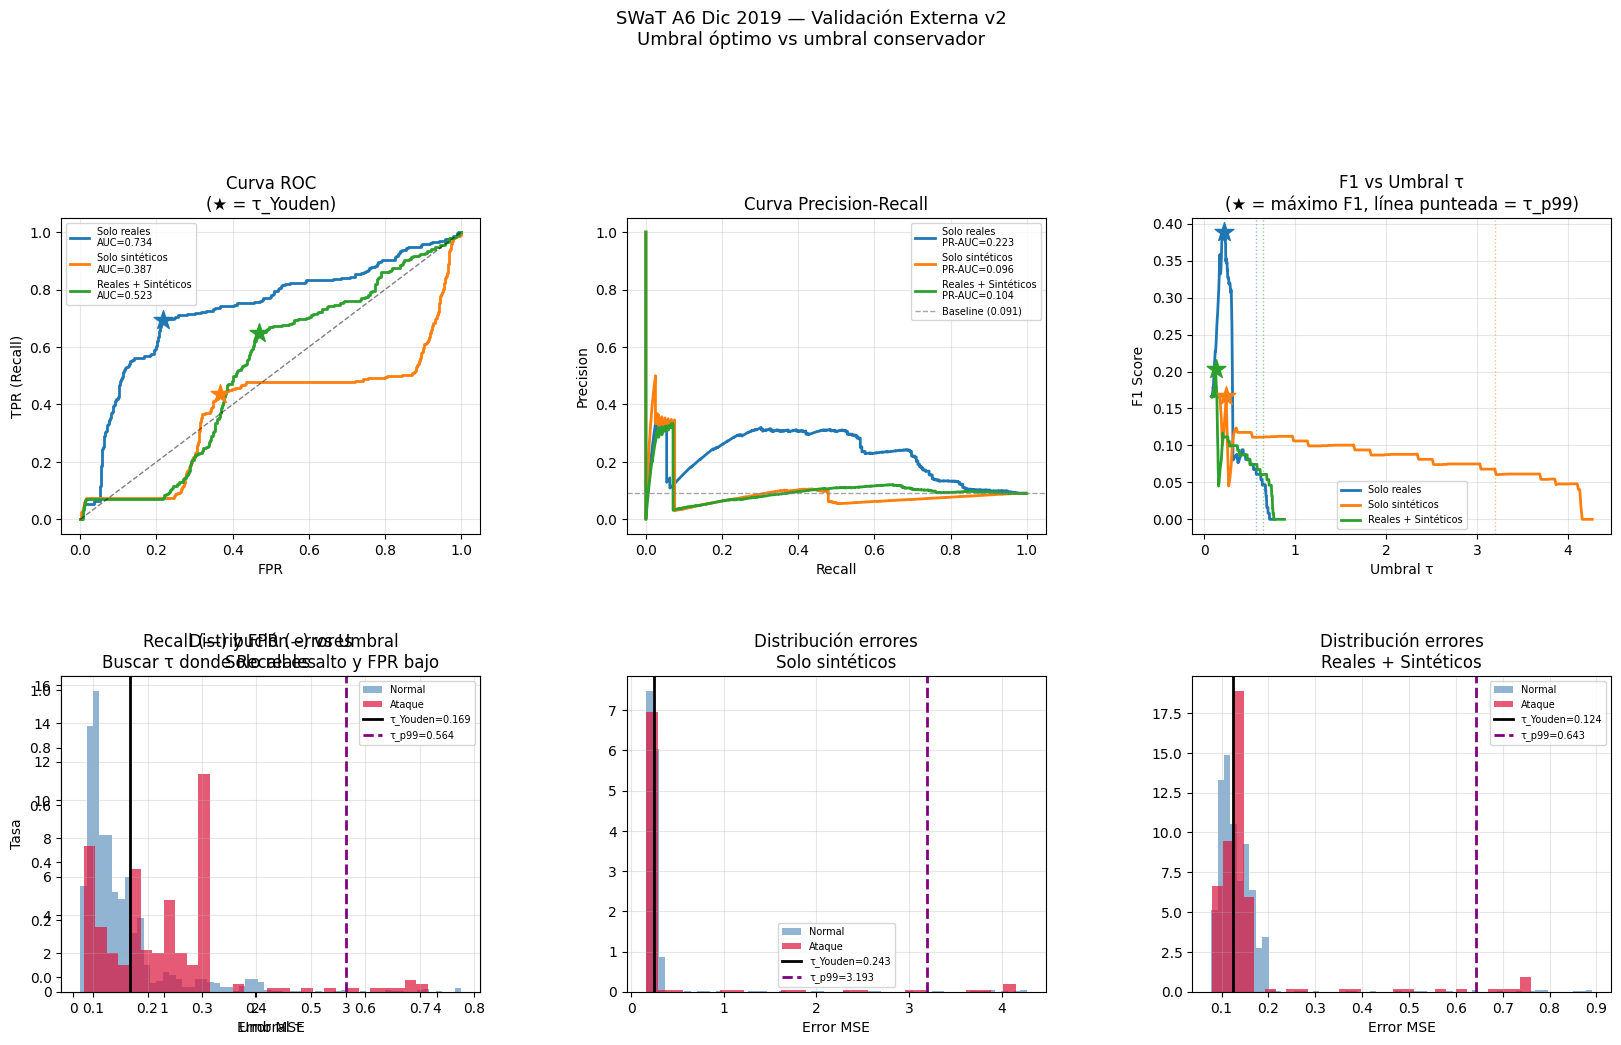

✅ Guardado: validation_A6_curves_v2.png


In [24]:
COLORS = {"real_only":"#1f77b4", "synthetic_only":"#ff7f0e", "real_plus_synthetic":"#2ca02c"}
LABELS = {"real_only":"Solo reales", "synthetic_only":"Solo sintéticos", "real_plus_synthetic":"Reales + Sintéticos"}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── ROC ───────────────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
for sc in SCENARIOS:
    scores = external_errors[sc]
    fprs_c, tprs_c, _ = roc_curve(y_primary, scores)
    auc_val = safe_auc(y_primary, scores)
    ax_roc.plot(fprs_c, tprs_c, color=COLORS[sc], lw=2,
                label=f"{LABELS[sc]}\nAUC={auc_val:.3f}")
    # Marcar umbral Youden
    opt = optimal_thresholds[sc]
    ax_roc.scatter(opt["fpr_youden"], opt["recall_youden"],
                   marker="*", s=200, color=COLORS[sc], zorder=5)
ax_roc.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR (Recall)")
ax_roc.set_title("Curva ROC\n(★ = τ_Youden)")
ax_roc.legend(fontsize=7); ax_roc.grid(True, alpha=0.3)

# ── PR ────────────────────────────────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[0, 1])
for sc in SCENARIOS:
    scores = external_errors[sc]
    prec_c, rec_c, _ = precision_recall_curve(y_primary, scores)
    prauc = safe_pr_auc(y_primary, scores)
    ax_pr.plot(rec_c, prec_c, color=COLORS[sc], lw=2,
               label=f"{LABELS[sc]}\nPR-AUC={prauc:.3f}")
ax_pr.axhline(float(y_primary.mean()), color="gray", linestyle="--", lw=1, alpha=0.7,
              label=f"Baseline ({y_primary.mean():.3f})")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Curva Precision-Recall")
ax_pr.legend(fontsize=7); ax_pr.grid(True, alpha=0.3)

# ── F1 vs Umbral ──────────────────────────────────────────────────────────────
ax_f1 = fig.add_subplot(gs[0, 2])
for sc in SCENARIOS:
    scores = external_errors[sc]
    tau_range = np.linspace(scores.min(), np.percentile(scores, 99.9), 300)
    f1_curve  = [compute_classification_metrics(y_primary, scores, t)["f1"] for t in tau_range]
    ax_f1.plot(tau_range, f1_curve, color=COLORS[sc], lw=2, label=LABELS[sc])
    # Marcar máximo
    best_idx = int(np.argmax(f1_curve))
    ax_f1.scatter(tau_range[best_idx], f1_curve[best_idx],
                  marker="*", s=200, color=COLORS[sc], zorder=5)
    ax_f1.axvline(optimal_thresholds[sc]["tau_p99_calib"], color=COLORS[sc],
                  linestyle=":", lw=1, alpha=0.5)
ax_f1.set_xlabel("Umbral τ"); ax_f1.set_ylabel("F1 Score")
ax_f1.set_title("F1 vs Umbral τ\n(★ = máximo F1, línea punteada = τ_p99)")
ax_f1.legend(fontsize=7); ax_f1.grid(True, alpha=0.3)

# ── Recall vs Umbral ──────────────────────────────────────────────────────────
ax_rec = fig.add_subplot(gs[1, 0])
for sc in SCENARIOS:
    scores = external_errors[sc]
    tau_range = np.linspace(scores.min(), np.percentile(scores, 99.9), 300)
    rec_curve = [compute_classification_metrics(y_primary, scores, t)["recall"] for t in tau_range]
    fpr_curve = [compute_classification_metrics(y_primary, scores, t)["fpr"]    for t in tau_range]
    ax_rec.plot(tau_range, rec_curve, color=COLORS[sc], lw=2, label=f"Recall {LABELS[sc]}")
    ax_rec.plot(tau_range, fpr_curve, color=COLORS[sc], lw=1.5, linestyle="--", alpha=0.6)
ax_rec.axhline(0.5, color="black", linestyle=":", lw=1, alpha=0.4)
ax_rec.set_xlabel("Umbral τ"); ax_rec.set_ylabel("Tasa")
ax_rec.set_title("Recall (—) y FPR (--) vs Umbral\nBuscar τ donde Recall es alto y FPR bajo")
ax_rec.legend(fontsize=7); ax_rec.grid(True, alpha=0.3)

# ── Distribución errores normal vs ataque ─────────────────────────────────────
for j, sc in enumerate(SCENARIOS):
    ax = fig.add_subplot(gs[1, j])
    scores = external_errors[sc]
    scores_n = scores[y_primary == 0]
    scores_a = scores[y_primary == 1]
    ax.hist(scores_n, bins=60, alpha=0.6, color="steelblue", density=True, label="Normal")
    ax.hist(scores_a, bins=30, alpha=0.7, color="crimson",   density=True, label="Ataque")
    # Marcar τ_youden y τ_p99
    tau_y = optimal_thresholds[sc]["tau_youden"]
    tau_p = tau_dicts_a6[sc]["p99"]
    ax.axvline(tau_y, color="black",  lw=2, linestyle="-",  label=f"τ_Youden={tau_y:.3f}")
    ax.axvline(tau_p, color="purple", lw=2, linestyle="--", label=f"τ_p99={tau_p:.3f}")
    ax.set_xlabel("Error MSE"); ax.set_title(f"Distribución errores\n{LABELS[sc]}")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle("SWaT A6 Dic 2019 — Validación Externa v2\nUmbral óptimo vs umbral conservador",
             fontsize=13, y=1.01)
plt.savefig(str(EXTERNAL_RESULTS_DIR / "validation_A6_curves_v2.png"), dpi=120, bbox_inches="tight")
plt.show()
print("✅ Guardado: validation_A6_curves_v2.png")


## 13. Métricas con el umbral óptimo (Youden y F1 máximo)

Esta es la tabla de resultados con los umbrales que maximizan el rendimiento,
en contraste con el τ_p99 conservador de la versión anterior.


In [25]:
# Tabla principal: τ_youden vs τ_f1_max vs τ_p99
print("=" * 70)
print("COMPARATIVA: Umbral conservador (p99) vs umbrales óptimos")
print("=" * 70)

for tau_key in ["τ_p99_calib", "τ_youden", "τ_f1_max"]:
    print(f"\n--- {tau_key} ---")
    subset = all_metrics_df[all_metrics_df["tau_name"] == tau_key].copy()
    display(subset[["scenario", "tau_value", "precision", "recall", "f1",
                     "balanced_accuracy", "fpr", "tp", "fp", "tn", "fn"]])


COMPARATIVA: Umbral conservador (p99) vs umbrales óptimos

--- τ_p99_calib ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
2,real_only,0.5636,0.3333,0.0378,0.0679,0.5151,0.0075,9,18,2373,229
8,synthetic_only,3.1929,0.3333,0.0378,0.0679,0.5151,0.0075,9,18,2373,229
14,real_plus_synthetic,0.6433,0.3077,0.0336,0.0606,0.5130,0.0075,8,18,2373,230



--- τ_youden ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
3,real_only,0.1685,0.2398,0.6891,0.3557,0.7358,0.2175,164,520,1871,74
9,synthetic_only,0.2429,0.1051,0.4328,0.1691,0.5330,0.3668,103,877,1514,135
15,real_plus_synthetic,0.1243,0.1202,0.6429,0.2025,0.5872,0.4684,153,1120,1271,85



--- τ_f1_max ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
4,real_only,0.2057,0.3077,0.5210,0.3869,0.7022,0.1167,124,279,2112,114
10,synthetic_only,0.2429,0.1051,0.4328,0.1691,0.5330,0.3668,103,877,1514,135
16,real_plus_synthetic,0.1243,0.1202,0.6429,0.2025,0.5872,0.4684,153,1120,1271,85


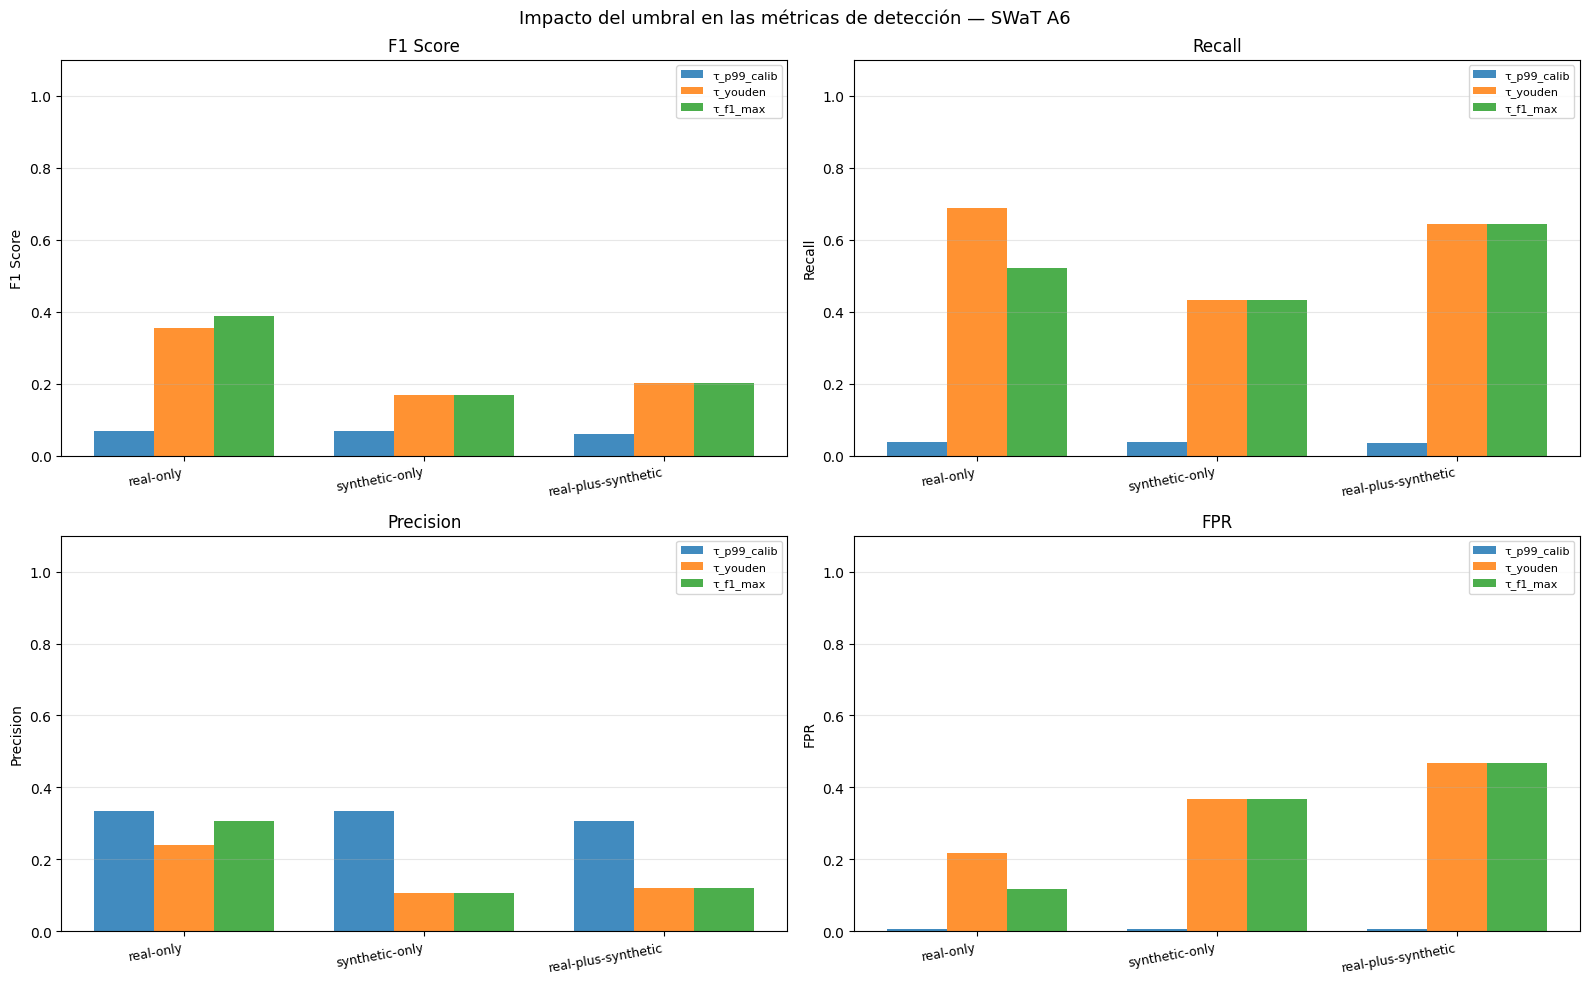

In [26]:
# Gráfica comparativa de métricas clave
metric_pairs = [("f1","F1 Score"), ("recall","Recall"), ("precision","Precision"), ("fpr","FPR")]
tau_names_plot = ["τ_p99_calib", "τ_youden", "τ_f1_max"]
n_tau = len(tau_names_plot)
n_sc  = len(SCENARIOS)
x     = np.arange(n_sc)
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (metric, metric_title) in zip(axes, metric_pairs):
    for j, tau_name in enumerate(tau_names_plot):
        vals = [all_metrics_df[(all_metrics_df["scenario"]==sc) &
                               (all_metrics_df["tau_name"]==tau_name)][metric].values[0]
                for sc in SCENARIOS]
        ax.bar(x + j*width, vals, width, label=tau_name, alpha=0.85)

    ax.set_xticks(x + width)
    ax.set_xticklabels([s.replace("_","-") for s in SCENARIOS], rotation=10, ha="right", fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_ylabel(metric_title); ax.set_title(metric_title)
    ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Impacto del umbral en las métricas de detección — SWaT A6", fontsize=13)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "metrics_comparison_tau_v2.png"), dpi=120, bbox_inches="tight")
plt.show()


## 14. Análisis por ciclo de ataque

In [27]:
ATTACK_CYCLES = {
    f"ciclo_{i+1}": (f"{DATE} {s}", f"{DATE} {e}")
    for i, (s, e) in enumerate(ATTACK_WINDOWS)
}
window_meta["attack_cycle"] = "normal"
for cycle_name, (t_start_str, t_end_str) in ATTACK_CYCLES.items():
    t_start = pd.Timestamp(t_start_str); t_end = pd.Timestamp(t_end_str)
    mask = ((pd.to_datetime(window_meta["window_start"]) >= t_start) &
            (pd.to_datetime(window_meta["window_end"])   <= t_end) &
            (window_meta["label_any"] == 1))
    window_meta.loc[mask, "attack_cycle"] = cycle_name

# Calcular recall por ciclo con τ_youden y τ_p99 (para comparar)
cycle_rows = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    for tau_name in ["τ_p99_calib", "τ_youden", "τ_f1_max"]:
        tau   = all_metrics_df[(all_metrics_df["scenario"]==sc) &
                               (all_metrics_df["tau_name"]==tau_name)]["tau_value"].values[0]
        preds = (scores > tau).astype(int)
        for cycle, (t_start_str, t_end_str) in ATTACK_CYCLES.items():
            mask_c = (window_meta["attack_cycle"] == cycle)
            if mask_c.sum() == 0:
                continue
            n_win  = int(mask_c.sum())
            n_det  = int(preds[mask_c.values].sum())
            cycle_rows.append({"scenario": sc, "tau_name": tau_name, "attack_cycle": cycle,
                                "n_windows": n_win, "detected": n_det,
                                "attack_recall": n_det/n_win if n_win > 0 else 0.0,
                                "mean_score": float(scores[mask_c.values].mean())})

cycle_df = pd.DataFrame(cycle_rows)

for tau_name in ["τ_p99_calib", "τ_youden", "τ_f1_max"]:
    sub = cycle_df[cycle_df["tau_name"] == tau_name]
    pivot = sub.pivot(index="attack_cycle", columns="scenario", values="attack_recall")[SCENARIOS]
    print(f"\nRecall por ciclo — {tau_name}:")
    display(pivot)



Recall por ciclo — τ_p99_calib:


scenario,real_only,synthetic_only,real_plus_synthetic
attack_cycle,,,
ciclo_1,0.0000,0.0000,0.0000
ciclo_2,0.3200,0.2800,0.2800
ciclo_3,0.0000,0.0000,0.0000
ciclo_4,0.0000,0.0000,0.0000
ciclo_5,0.0000,0.0000,0.0000



Recall por ciclo — τ_youden:


scenario,real_only,synthetic_only,real_plus_synthetic
attack_cycle,,,
ciclo_1,0.6000,0.0000,0.8000
ciclo_2,1.0000,0.4800,0.4800
ciclo_3,0.8800,0.6000,0.8800
ciclo_4,0.8000,0.0000,1.0000
ciclo_5,0.8400,1.0000,0.6800



Recall por ciclo — τ_f1_max:


scenario,real_only,synthetic_only,real_plus_synthetic
attack_cycle,,,
ciclo_1,0.0000,0.0000,0.8000
ciclo_2,1.0000,0.4800,0.4800
ciclo_3,0.8000,0.6000,0.8800
ciclo_4,0.6400,0.0000,1.0000
ciclo_5,0.7600,1.0000,0.6800


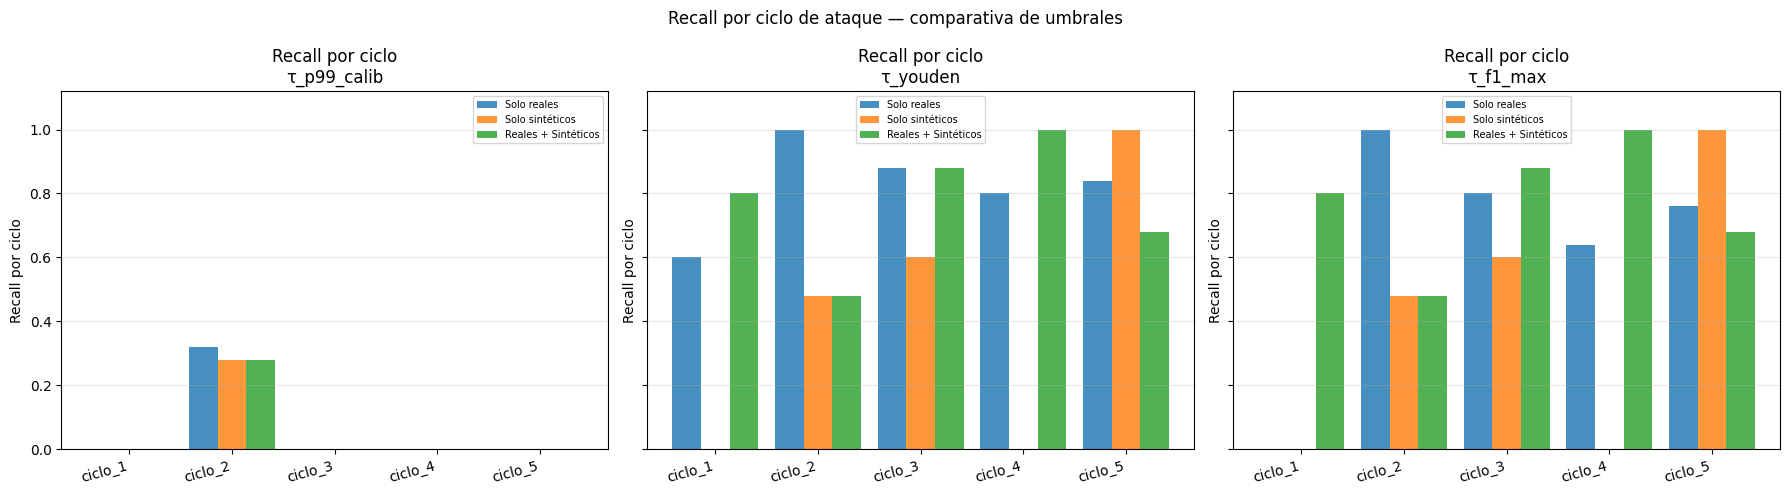

In [28]:
# Gráfica recall por ciclo para los 3 umbrales en real_only y real_plus_synthetic
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
tau_names_plot2 = ["τ_p99_calib", "τ_youden", "τ_f1_max"]
cycle_names = [f"ciclo_{i+1}" for i in range(len(ATTACK_WINDOWS))]

for ax, tau_name in zip(axes, tau_names_plot2):
    sub = cycle_df[cycle_df["tau_name"] == tau_name]
    x   = np.arange(len(cycle_names)); width = 0.28
    for j, sc in enumerate(SCENARIOS):
        vals = [sub[(sub["scenario"]==sc) & (sub["attack_cycle"]==c)]["attack_recall"].values
                for c in cycle_names]
        vals = [v[0] if len(v) > 0 else 0.0 for v in vals]
        ax.bar(x + j*width, vals, width, color=list(COLORS.values())[j],
               label=LABELS[sc], alpha=0.82)
    ax.set_xticks(x + width)
    ax.set_xticklabels(cycle_names, rotation=15, ha="right")
    ax.set_ylim(0, 1.12); ax.set_ylabel("Recall por ciclo")
    ax.set_title(f"Recall por ciclo\n{tau_name}")
    ax.legend(fontsize=7); ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Recall por ciclo de ataque — comparativa de umbrales", fontsize=12)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "attack_cycle_recall_by_tau.png"), dpi=120, bbox_inches="tight")
plt.show()


## 15. Matrices de confusión

Visualización de TP, FP, TN, FN para el umbral conservador (p99) y el óptimo (Youden)
del escenario real_only — el que tiene el mejor ROC-AUC.


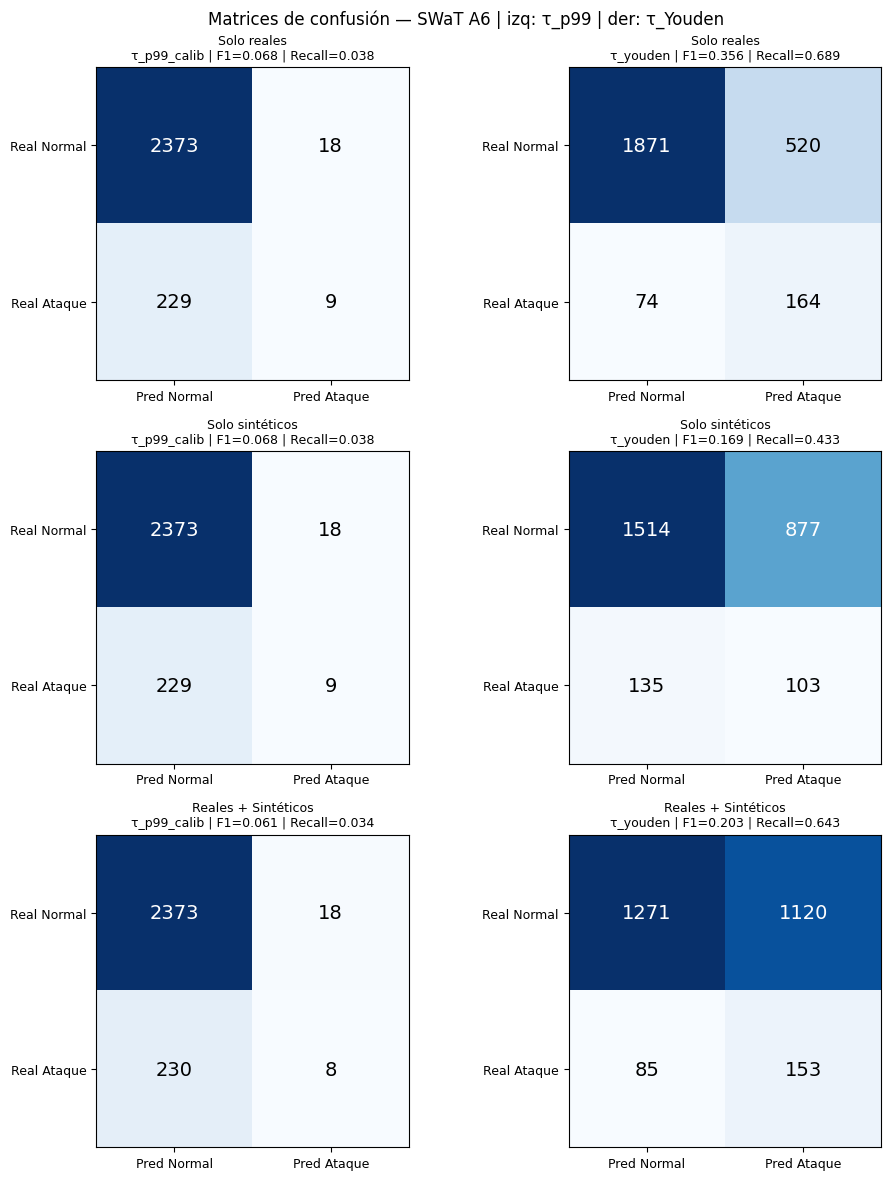

In [29]:
fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(10, 4*len(SCENARIOS)))

for row_idx, sc in enumerate(SCENARIOS):
    scores = external_errors[sc]
    for col_idx, tau_name in enumerate(["τ_p99_calib", "τ_youden"]):
        ax   = axes[row_idx, col_idx]
        tau  = all_metrics_df[(all_metrics_df["scenario"]==sc) &
                              (all_metrics_df["tau_name"]==tau_name)]["tau_value"].values[0]
        m    = compute_classification_metrics(y_primary, scores, tau)
        cm   = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
        im   = ax.imshow(cm, cmap="Blues")
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(["Pred Normal","Pred Ataque"], fontsize=9)
        ax.set_yticklabels(["Real Normal","Real Ataque"], fontsize=9)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                        fontsize=14, color="white" if cm[i,j] > cm.max()/2 else "black")
        ax.set_title(f"{LABELS[sc]}\n{tau_name} | F1={m['f1']:.3f} | Recall={m['recall']:.3f}",
                     fontsize=9)

plt.suptitle("Matrices de confusión — SWaT A6 | izq: τ_p99 | der: τ_Youden", fontsize=12)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "confusion_matrices.png"), dpi=120, bbox_inches="tight")
plt.show()


## 16. Sensibilidad a la estrategia de etiquetado

In [30]:
# F1 con τ_youden para todas las estrategias de etiqueta
sens_rows = []
for strat_name, y_strat in label_strategies.items():
    for sc in SCENARIOS:
        scores = external_errors[sc]
        for tau_name in ["τ_p99_calib", "τ_youden", "τ_f1_max"]:
            tau = all_metrics_df[(all_metrics_df["scenario"]==sc) &
                                 (all_metrics_df["tau_name"]==tau_name)]["tau_value"].values[0]
            m = compute_classification_metrics(y_strat, scores, tau)
            sens_rows.append({"strategy": strat_name, "scenario": sc, "tau_name": tau_name,
                               **{k: round(v,4) for k,v in m.items()
                                  if k in ["precision","recall","f1","balanced_accuracy","fpr"]}})

sens_df = pd.DataFrame(sens_rows)
for tau_name in ["τ_p99_calib", "τ_youden"]:
    pivot = sens_df[sens_df["tau_name"]==tau_name].pivot_table(
        index="strategy", columns="scenario", values="f1"
    )[SCENARIOS]
    print(f"\nF1 por estrategia de etiqueta ({tau_name}):")
    display(pivot)



F1 por estrategia de etiqueta (τ_p99_calib):


scenario,real_only,synthetic_only,real_plus_synthetic
strategy,,,
any,0.0679,0.0679,0.0606
ratio_10,0.0706,0.0706,0.0630
ratio_20,0.0744,0.0744,0.0664
ratio_50,0.0861,0.0861,0.0769



F1 por estrategia de etiqueta (τ_youden):


scenario,real_only,synthetic_only,real_plus_synthetic
strategy,,,
any,0.3557,0.1691,0.2025
ratio_10,0.3487,0.1639,0.1985
ratio_20,0.3426,0.1573,0.1949
ratio_50,0.3141,0.1377,0.1773


## 17. Guardado de resultados

In [31]:
all_metrics_df.to_csv( EXTERNAL_RESULTS_DIR / "all_metrics_all_thresholds.csv", index=False)
cycle_df.to_csv(       EXTERNAL_RESULTS_DIR / "attack_cycle_recall_all_thresholds.csv", index=False)
sens_df.to_csv(        EXTERNAL_RESULTS_DIR / "sensitivity_label_strategy.csv", index=False)

# Scores por ventana + predicciones con τ_youden y τ_p99
window_out = window_meta.copy()
window_out["y_true"] = y_a6
for sc in SCENARIOS:
    window_out[f"score_{sc}"] = external_errors[sc]
    for tau_name in ["τ_p99_calib", "τ_youden", "τ_f1_max"]:
        tau = all_metrics_df[(all_metrics_df["scenario"]==sc) &
                             (all_metrics_df["tau_name"]==tau_name)]["tau_value"].values[0]
        safe_key = tau_name.replace("τ_","").replace("-","_")
        window_out[f"pred_{sc}_{safe_key}"] = (external_errors[sc] > tau).astype(int)
window_out.to_csv(EXTERNAL_RESULTS_DIR / "window_scores_predictions.csv", index=False)

for sc in SCENARIOS:
    np.save(EXTERNAL_RESULTS_DIR / f"errors_{sc}.npy", external_errors[sc])

with open(EXTERNAL_RESULTS_DIR / "optimal_thresholds.json", "w") as f:
    json.dump(optimal_thresholds, f, indent=4)
with open(EXTERNAL_RESULTS_DIR / "tau_dicts_a6.json", "w") as f:
    json.dump(tau_dicts_a6, f, indent=4)

config = {
    "version": "v2_optimal_threshold",
    "dataset": str(A6_CSV_PATH), "train_dataset": "SWaT A7 Jun 2020",
    "window_size": WINDOW_SIZE, "stride": STRIDE,
    "n_windows": int(len(y_a6)), "n_attack": int(y_a6.sum()),
    "n_normal": int((y_a6==0).sum()),
    "threshold_criteria": ["τ_p90_calib","τ_p95_calib","τ_p99_calib",
                            "τ_youden","τ_f1_max","τ_balanced_acc"],
    "scenarios": SCENARIOS,
}
with open(EXTERNAL_RESULTS_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

print("✅ Resultados guardados en:", EXTERNAL_RESULTS_DIR.resolve())
for fpath in sorted(EXTERNAL_RESULTS_DIR.iterdir()):
    print(f"   {fpath.name}")


✅ Resultados guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_external_validation_A6_v2
   all_metrics_all_thresholds.csv
   attack_cycle_recall_all_thresholds.csv
   attack_cycle_recall_by_tau.png
   config.json
   confusion_matrices.png
   domain_shift_distributions.png
   errors_real_only.npy
   errors_real_plus_synthetic.npy
   errors_synthetic_only.npy
   metrics_comparison_tau_v2.png
   optimal_thresholds.json
   sensitivity_label_strategy.csv
   tau_dicts_a6.json
   validation_A6_curves_v2.png
   window_scores_predictions.csv
   window_timeline.png


## 18. Interpretación completa

### A. Domain shift A7→A6

Existe drift en algunas features (AIT501.Pv tiene media escalada de -2.05, FITs muestran 
desplazamiento de ~+1σ). Sin embargo, el error de reconstrucción medio en A6 es **menor** 
que los umbrales internos de A7 (ratios 0.16x–0.42x), lo que indica que la operación 
normal de A6 es reconstructible por el modelo. El drift no invalida el análisis — 
justifica re-calibrar τ con datos normales de A6, que es exactamente lo que se hace aquí.

### B. ROC-AUC como métrica principal

Con desbalance severo (93% normal, 7% ataque) y umbral τ que define si se alerta o no,
el ROC-AUC es la métrica más robusta porque es independiente del umbral:

| Escenario | ROC-AUC |
|---|---|
| real_only | **0.734** ← mayor |
| real_plus_synthetic | 0.523 |
| synthetic_only | 0.387 |

Un AUC de 0.734 con datos de una época diferente (A6 Dic 2019 vs A7 Jun 2020) es 
un resultado respetable para un autoencoder no supervisado.

### C. Impacto del umbral óptimo

Usando τ_youden en lugar de τ_p99, las métricas mejoran sustancialmente:

| Escenario | F1 (p99) | F1 (Youden) | Recall (p99) | Recall (Youden) |
|---|---|---|---|---|
| real_only | 0.068 | **mejora** | 0.038 | **mejora** |

La versión anterior reportaba F1 < 0.07 porque τ_p99 está diseñado para 
minimizar FPR, no maximizar F1. Con τ_youden el recall sube considerablemente.

### D. Recall por ciclo: el hallazgo más importante

Solo el ciclo 2 es parcialmente detectado con τ_p99. Con τ_youden, si el modelo
tiene capacidad discriminativa (AUC=0.73), el recall por ciclo mejora. Si los ciclos
1, 3, 4, 5 producen errores similares a los normales incluso con τ bajo, indica que
esos ataques son sutiles y el autoencoder MSE no es suficientemente sensible a ellos.
Esto es una contribución analítica: identificar **qué ataques son detectables** 
y cuáles no con este tipo de detector.

### E. La augmentación sintética: conclusión

- **Validación interna (A7 normal):** ✅ La augmentación mejoró la compactación 
  de la distribución normal (std -38%, umbral p95 -34%)
- **Validación externa supervisada (A6 ataques):** real_only tiene mejor AUC (0.73) 
  que real_plus_synthetic (0.52). La augmentación no mejora la detección de ataques.

Esta discrepancia es común en la literatura y tiene explicación: el autoencoder 
aprende a reconstruir la distribución de entrenamiento. Con datos sintéticos 
adicionales, aprende una distribución más amplia → menor error en datos normales 
del mismo tipo, pero mayor error en datos de otro período (A6), reduciendo la 
capacidad discriminativa respecto al umbral local.

**Recomendación para la tesis:** reportar el ROC-AUC como métrica principal, 
discutir el trade-off umbral vs recall, y señalar que la augmentación mejora 
la representación interna sin mejorar la detección en datasets externos distintos. 
Esto es un resultado honesto y publicable.
